# Creación BD S&P500

La idea es que del dataset con los precios, se tome el último día y se resten 1000 días, después se compare con el otro dataset de tickers para evaluar el sesgo de supervivencia. Los enlaces a dichos datasets se encuentran a continuación:

Dataset con la información de precios: https://www.kaggle.com/datasets/camnugent/sandp500?resource=download

Dataset con la información de tickers: https://github.com/fja05680/sp500

In [1]:
import pandas as pd
import os
import numpy as np
import pandas_market_calendars as mcal
import matplotlib.pyplot as plt


In [2]:
# ---------------------------------------------------------
# BLOQUE 1: Configuración de Rutas y Carga Inicial
# ---------------------------------------------------------
folder_path = r'../../../data/processed'
path_main = os.path.join(folder_path, 'dataset_with_returns.csv')
path_components = os.path.join(folder_path, 'S&P 500 Historical Components & Changes(01-17-2026).csv')

print("Cargando dataset principal...")
df = pd.read_csv(path_main)
df['date'] = pd.to_datetime(df['date'])

# Aseguramos el orden cronológico para que el recorte de registros sea correcto
df = df.sort_values(['Name', 'date'])

df.head()

Cargando dataset principal...


,date,open,high,low,close,volume,Name,adjusted_price,return_1d
0,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,28.576422,-0.010648
1,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,28.589230,0.000448
2,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,28.672525,0.002914
3,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,28.563612,-0.003799
4,2013-02-15,43.48,44.24,42.21,42.25,14657315,A,27.070713,-0.052266


### Checking if there are dates gaps

In [3]:
def detect_real_gaps(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["Name", "date"])

    nyse = mcal.get_calendar("NYSE")

    gaps = []

    for name, group in df.groupby("Name"):
        group = group.sort_values("date").reset_index(drop=True)

        for i in range(1, len(group)):
            prev_date = group.loc[i-1, "date"]
            curr_date = group.loc[i, "date"]

            valid_days = nyse.valid_days(start_date=prev_date, end_date=curr_date)

            # deberían ser 2: prev y next
            if len(valid_days) > 2:
                gaps.append({
                    "Name": name,
                    "prev_date": prev_date,
                    "date": curr_date,
                    "missing_days": valid_days[1:-1]
                })

    return pd.DataFrame(gaps)
    
detect_real_gaps(df).shape

(17, 4)

### Avoiding survivor bias

To eliminate survivor bias, we first obtain all month-end constituent lists 
for the S&P 500 from January 2013 to December 2018. We consolidate these lists 
into a single binary matrix, indicating whether each stock is an index 
constituent in the subsequent month. In this way, we are able to approximately 
reproduce the S&P 500 composition at any point in time within this period. 
In a second step, for all stocks that have been constituents of the index at 
any time during this interval, we download daily total return indices covering 
the same time frame.

In [4]:
folder_path = r'../../../data/raw'
path_components = os.path.join(folder_path, 'S&P 500 Historical Components & Changes(01-17-2026).csv')
df_hist_comp = pd.read_csv(path_components)
df_hist_comp['date'] = pd.to_datetime(df_hist_comp['date'])

print(df_hist_comp.head())
print("...")
print(df_hist_comp.tail())

        date                                            tickers
0 1996-01-02  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
1 1996-01-03  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
2 1996-01-04  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
3 1996-01-10  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
4 1996-01-11  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
...
           date                                            tickers
2700 2025-11-11  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2701 2025-11-28  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2702 2025-12-11  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2703 2025-12-22  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2704 2026-01-14  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...


In [5]:
df_hist_comp.dtypes

date       datetime64[us]
tickers               str
dtype: object

In [6]:
df.head()
first_date = df.iloc[0]['date']
print(first_date)

last_date = df.iloc[-1]['date']
print(last_date)

2013-02-11 00:00:00
2018-02-07 00:00:00


Creating pandas tables to see which companies were on S&P 500 at the end of the month

In [7]:
# Filtrar por fechas
df_hist_comp = df_hist_comp[(df_hist_comp['date'] >= first_date) & (df_hist_comp['date'] <= last_date)].copy()

# Extraer año y mes
df_hist_comp['year'] = df_hist_comp['date'].dt.year
df_hist_comp['month'] = df_hist_comp['date'].dt.month

# Tomar último día de cada mes
df_month_end = df_hist_comp.groupby(['year', 'month']).tail(1)

# Eliminar la columna 'date'
df_month_end = df_month_end.drop(columns=['date'])

# Reordenar columnas para que year y month queden primero
cols = ['year', 'month'] + [c for c in df_month_end.columns if c not in ['year', 'month']]
df_month_end = df_month_end[cols]

df_month_end = df_month_end.reset_index(drop=True)

# Revisar resultado
print(df_month_end.head())
print("...")
print(df_month_end.tail())

   year  month                                            tickers
0  2013      2  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
1  2013      3  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
2  2013      4  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
3  2013      5  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
4  2013      6  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
...
    year  month                                            tickers
56  2017     10  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
57  2017     11  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
58  2017     12  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
59  2018      1  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
60  2018      2  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...


Creating Binary matrix

In [8]:
all_tickers = set()

for tickers_str in df_hist_comp['tickers']:
    for t in tickers_str.split(','):
        all_tickers.add(t.strip())
all_tickers = sorted(all_tickers)

ticker_dict = {ticker: idx for idx, ticker in enumerate(all_tickers)}


n_months = len(df_month_end)
n_tickers = len(all_tickers)

# matriz de ceros
binary_matrix = np.zeros((n_months, n_tickers), dtype=int)

for i, row in df_month_end.iterrows():
    tickers_in_row = row['tickers'].split(',')  # separa los tickers
    for t in tickers_in_row:
        t = t.strip()  # quitar espacios
        if t in ticker_dict:  # seguridad
            j = ticker_dict[t]  # columna correspondiente
            binary_matrix[i, j] = 1


binary_df = pd.DataFrame(binary_matrix, columns=all_tickers)
binary_df.insert(0, 'year', df_month_end['year'])
binary_df.insert(1, 'month', df_month_end['month'])

print(binary_df.head())

   year  month  A  AABA  AAL  AAP  AAPL  ABBV  ABC  ABT  ...  XL  XLNX  XOM  \
0  2013      2  1     1    0    0     1     1    1    1  ...   1     1    1   
1  2013      3  1     1    0    0     1     1    1    1  ...   1     1    1   
2  2013      4  1     1    0    0     1     1    1    1  ...   1     1    1   
3  2013      5  1     1    0    0     1     1    1    1  ...   1     1    1   
4  2013      6  1     1    0    0     1     1    1    1  ...   1     1    1   

   XRAY  XRX  XYL  YUM  ZBH  ZION  ZTS  
0     1    1    1    1    1     1    0  
1     1    1    1    1    1     1    0  
2     1    1    1    1    1     1    0  
3     1    1    1    1    1     1    0  
4     1    1    1    1    1     1    1  

[5 rows x 619 columns]


### Create rolling windows

#### Paso 1: Definir los bloques de 1000 dias

In [9]:
WINDOW_SIZE = 240

training_days = 750
trading_days = 250

df_rolling_windows = df  

all_dates = pd.bdate_range(start=df['date'].min(), end=df['date'].max())

study_period_days = training_days + trading_days + WINDOW_SIZE

start_idx = 0
study_periods = []

while start_idx + study_period_days <= len(all_dates):
    period_dates = all_dates[start_idx:start_idx + study_period_days]
    
    study_periods.append({
        'block_dates': period_dates,  
    })
    
    start_idx += trading_days  

print(len(study_periods))

1


Solo tendremos 1 periodo de estudio

#### Paso 2: Filtrar tickers usando la matriz binaria

This function is made so it search the companies that were on S&P500 the last month of the 1000 blocks day

In [10]:
def get_tickers_for_period(binary_df, last_train_date):
    year = last_train_date.year
    month = last_train_date.month
    
    row = binary_df[
        (binary_df['year'] == year) &
        (binary_df['month'] == month)
    ]
    
    if row.empty:
        return []
    
    tickers_series = row.drop(columns=['year', 'month']).iloc[0]
    tickers = tickers_series[tickers_series == 1].index.tolist()
    
    return tickers


Create study periods with metadata

In [11]:
study_periods_data = []

for i, period in enumerate(study_periods):
    
    last_train_date = pd.to_datetime(period['block_dates'][-250])
    
    tickers = get_tickers_for_period(binary_df, last_train_date)
    
    df_1240_days = df_rolling_windows[
        (df_rolling_windows['Name'].isin(tickers)) &
        (df_rolling_windows['date'].isin(period['block_dates']))
    ].copy()
    

    # Guardar todo
    study_periods_data.append({
        'period_id': i,
        'tickers': tickers,
        'n_i': len(tickers),
        '1240_days_df': df_1240_days,
        '1240_days_start': period['block_dates'][0],
        '1240_days_end': period['block_dates'][-1],
    })



In [12]:
for sp in study_periods_data:
    print(f"\nStudy Period {sp['period_id']}")
    print(f"n_i: {sp['n_i']}")
    print(f"data range: {sp['1240_days_start']} → {sp['1240_days_end']}")
    print(f"#data rows: {len(sp['1240_days_df'])}")



Study Period 0
n_i: 506
data range: 2013-02-11 00:00:00 → 2017-11-10 00:00:00
#data rows: 551251


### Standarized returns only with traininng dataset

In [37]:
for sp in study_periods_data:
    # 1. Extraer el DataFrame de los 1,000 días del bloque actual
    df_block = sp['1240_days_df'].copy() 
    
    # 2. Obtener los retornos solo del periodo de entrenamiento (primeros 750 días)
    # Nota: Asegúrate de que df_block esté ordenado por fecha
    train_returns = df_block.iloc[:training_days]['return_1d']
    
    # 3. Calcular media y desviación estándar del entrenamiento (Ecuación 2 del paper)
    mu_train = train_returns.mean()
    sigma_train = train_returns.std()
    
    # 4. Aplicar la estandarización a TODO el bloque (entrenamiento + trading)
    # Esto genera el R_tilde descrito en el paper [1]
    df_block['standardized_return'] = (df_block['return_1d'] - mu_train) / sigma_train
    
    # 5. Actualizar el DataFrame en tu diccionario de periodos de estudio
    sp['1240_days_df'] = df_block

### Create rolling windows for each stock

In [38]:
def calculate_returns(df, price_col="price"):
    
    df["return_1d"] = df['standardized_return']

    return df

def create_sequences_for_stock_s(df):
    df = calculate_returns(df)
    sequences_for_ticker = []
    dates_for_ticker = [] # NUEVA LISTA

    window_size = WINDOW_SIZE

    # Ajuste de índices para coincidir con Pandas
    for i in range(window_size - 1, len(df)):
        window = df.iloc[i - window_size + 1 : i + 1]["return_1d"].values
        target_date = df.iloc[i]["date"] # CAPTURAMOS LA FECHA DE R_0
        
        window = window.reshape(-1, 1)
        sequences_for_ticker.append(window)
        dates_for_ticker.append(target_date)

    return sequences_for_ticker, dates_for_ticker
         
def build_sequences_dataset_for_study_period(sp):
    sequences = []
    dates = []  # NUEVA LISTA para agrupar las fechas
    tickers = sp.get('tickers', [])
    df_1240_days = sp.get('1240_days_df')
    
    for t in tickers:
        df_ticker = df_1240_days[df_1240_days["Name"] == t]
        
        # Desempaquetamos los dos valores que ahora devuelve la función
        sequences_for_ticker, dates_for_ticker = create_sequences_for_stock_s(df_ticker)
        
        sequences.append(sequences_for_ticker)
        dates.append(dates_for_ticker) # Guardamos las fechas

    # Retornamos ambas listas
    return sequences, dates

# Bucle actualizado para guardar ambos resultados en el diccionario sp
for sp in study_periods_data:
    seqs_built, dates_built = build_sequences_dataset_for_study_period(sp)
    sp["sequences_dataset"] = seqs_built
    sp["dates_dataset"] = dates_built  # Guardamos las fechas en el diccionario
    

In [39]:
def debug_sequences(sp, max_tickers=3, max_sequences=2):
    sequences = sp.get("sequences_dataset", [])
    tickers = sp.get("tickers", [])

    print(f"\nStudy Period {sp['period_id']}")
    print(f"Total tickers: {len(sequences)}")
    for i, (ticker, ticker_sequences) in enumerate(zip(tickers, sequences)):
        if i >= max_tickers:
            break

        print(f"\nTicker: {ticker}")
        print(f"Total sequences: {len(ticker_sequences)}")

        for j, seq in enumerate(ticker_sequences[:max_sequences]):
            print(f"  Seq {j} shape: {seq.shape}")
            print(f"  First 3 values: {seq[:3].flatten()}")

debug_sequences(study_periods_data[0])


Study Period 0
Total tickers: 467

Ticker: A
Total sequences: 960
  Seq 0 shape: (240, 1)
  First 3 values: [-0.76898359  0.00841448  0.18114136]
  Seq 1 shape: (240, 1)
  First 3 values: [ 0.00841448  0.18114136 -0.28911972]

Ticker: AAL
Total sequences: 960
  Seq 0 shape: (240, 1)
  First 3 values: [-1.40046138 -0.94359615  1.89181252]
  Seq 1 shape: (240, 1)
  First 3 values: [-0.94359615  1.89181252 -3.22500301]

Ticker: AAP
Total sequences: 960
  Seq 0 shape: (240, 1)
  First 3 values: [-0.47588753  0.16472946  0.30678   ]
  Seq 1 shape: (240, 1)
  First 3 values: [ 0.16472946  0.30678    -0.13831279]


We note that there are som Tickers/Stock that do not have sequences. Probably because they were not on the original data

In [40]:
def get_empty_sequence_tickers(sp):
    sequences = sp.get("sequences_dataset", [])
    tickers = sp.get("tickers", [])

    empty_tickers = []

    for ticker, ticker_sequences in zip(tickers, sequences):
        if len(ticker_sequences) == 0:
            empty_tickers.append(ticker)

    return empty_tickers


In [41]:
def inspect_missing_tickers(empty_tickers, df):
    for t in empty_tickers:
        df_t = df[df["Name"] == t]

        print(f"\nTicker: {t}")
        print(f"Rows in original df: {len(df_t)}")

        if len(df_t) > 0:
            print(f"Date range: {df_t['date'].min()} → {df_t['date'].max()}")
            print(f"Unique dates: {df_t['date'].nunique()}")
        else:
            
            print("⚠️ Not present in original dataset")

for sp in study_periods_data:
    print(f"\nStudy Period {sp['period_id']}")
    empty = get_empty_sequence_tickers(sp)
    inspect_missing_tickers(empty, df)


Study Period 0


We will remove those not present in the original dataset.

In [42]:
def get_invalid_tickers(empty_tickers, df, min_len=WINDOW_SIZE):
    invalid = []

    for t in empty_tickers:
        df_t = df[df["Name"] == t]

        # no está en el dataset o no tiene suficientes datos
        if len(df_t) == 0 or len(df_t) < min_len:
            invalid.append(t)

    return invalid

def remove_invalid_tickers_from_sp(sp, invalid_tickers):
    tickers = sp.get("tickers", [])
    sequences = sp.get("sequences_dataset", [])

    new_tickers = []
    new_sequences = []

    for t, seq in zip(tickers, sequences):
        if t not in invalid_tickers:
            new_tickers.append(t)
            new_sequences.append(seq)

    sp["tickers"] = new_tickers
    sp["sequences_dataset"] = new_sequences

    return 

for sp in study_periods_data:
    empty = get_empty_sequence_tickers(sp)
    invalid = get_invalid_tickers(empty, df)
    remove_invalid_tickers_from_sp(sp, invalid)

### Build lstm dataset

In [43]:
def sequences_to_dataframe(sp):
    sequences = sp.get("sequences_dataset", [])
    dates = sp.get("dates_dataset", []) 
    tickers = sp.get("tickers", [])

    rows = []

    # Nombres de columnas: R_-239 ... R_0
    start_window = WINDOW_SIZE - 1
    col_names = [f"R_{-i}" for i in reversed(range(WINDOW_SIZE))]
    
    # Iteramos sobre tickers, secuencias y fechas en paralelo
    for ticker, ticker_sequences, ticker_dates in zip(tickers, sequences, dates):
        for seq, date in zip(ticker_sequences, ticker_dates):
            seq_flat = seq.flatten() 

            row = dict(zip(col_names, seq_flat))
            row["ticker"] = ticker
            row["date"] = date 

            rows.append(row)

    df_sequences = pd.DataFrame(rows)
    return df_sequences


In [44]:
for sp in study_periods_data:
    df_sequences = sequences_to_dataframe(sp)
    sp["df_sequences"] = df_sequences


In [45]:
for sp in study_periods_data:
    print(f"\nStudy Period {sp['period_id']}")
    df_sequences = sp.get("df_sequences")
    print(df_sequences.shape)


Study Period 0
(439546, 242)


# Creating targets



In [46]:
def add_target_with_pandas(df_sequences):
    df = df_sequences.copy()

    # 1. obtener retorno futuro (t+1) por ticker
    df["R_t+1"] = df.groupby("ticker")["R_0"].shift(-1)

    # 2. índice temporal dentro de cada ticker
    df["time_idx"] = df.groupby("ticker").cumcount()

    # 3. mediana cross-sectional por tiempo
    df["median_t+1"] = df.groupby("time_idx")["R_t+1"].transform("median")

    
    # 4. asignar clase
    df["target"] = (df["R_t+1"] >= df["median_t+1"]).astype(int)
    df = df.drop(columns=["median_t+1", "R_t+1", "time_idx"])
    


    return df

In [47]:
for sp in study_periods_data:
    df_seq = sp.get("df_sequences")
    df_with_target = add_target_with_pandas(df_seq)
    sp["df_sequences"] = df_with_target
    print(f"Target calculado para Periodo {sp['period_id']}")

Target calculado para Periodo 0


In [48]:

print(f"\nStudy Period {sp['period_id']}")
df_sequences = study_periods_data[0].get("df_sequences")
df_sequences.head()


Study Period 0


,R_-239,R_-238,R_-237,R_-236,R_-235,R_-234,R_-233,R_-232,R_-231,R_-230,...,R_-6,R_-5,R_-4,R_-3,R_-2,R_-1,R_0,ticker,date,target
0,-0.768984,0.008414,0.181141,-0.289120,-3.684832,1.237274,-1.277278,-1.034766,0.263101,-0.877796,...,1.106459,0.515260,0.162772,0.220213,0.138572,0.069141,-1.701827,A,2014-01-23,0
1,0.008414,0.181141,-0.289120,-3.684832,1.237274,-1.277278,-1.034766,0.263101,-0.877796,-0.565976,...,0.515260,0.162772,0.220213,0.138572,0.069141,-1.701827,-1.907957,A,2014-01-24,1
2,0.181141,-0.289120,-3.684832,1.237274,-1.277278,-1.034766,0.263101,-0.877796,-0.565976,1.276668,...,0.162772,0.220213,0.138572,0.069141,-1.701827,-1.907957,0.497611,A,2014-01-27,0
3,-0.289120,-3.684832,1.237274,-1.277278,-1.034766,0.263101,-0.877796,-0.565976,1.276668,-0.442705,...,0.220213,0.138572,0.069141,-1.701827,-1.907957,0.497611,-0.263311,A,2014-01-28,1
4,-3.684832,1.237274,-1.277278,-1.034766,0.263101,-0.877796,-0.565976,1.276668,-0.442705,0.737066,...,0.138572,0.069141,-1.701827,-1.907957,0.497611,-0.263311,-0.565664,A,2014-01-29,1


Periodo 0


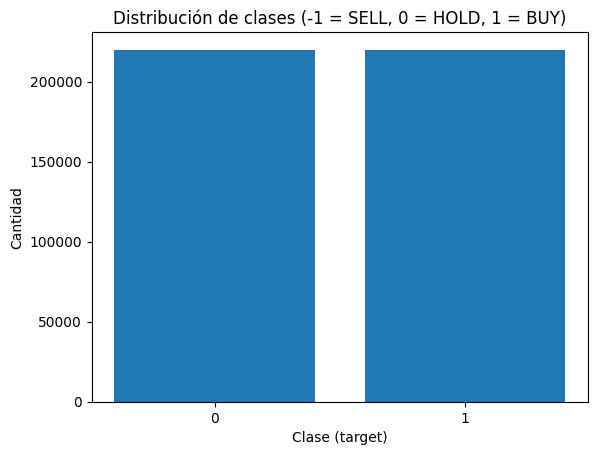

In [49]:
# Conteo de clases
def plot_targets(df):
    counts = df["target"].value_counts().sort_index()
    
    # Plot
    plt.figure()
    plt.bar(counts.index.astype(str), counts.values)
    
    plt.xlabel("Clase (target)")
    plt.ylabel("Cantidad")
    plt.title("Distribución de clases (-1 = SELL, 0 = HOLD, 1 = BUY)")
    
    plt.show()
    plt.close()

for i, sp in enumerate(study_periods_data):
    df_seq = sp.get("df_sequences")
    
    print(f"Periodo {i}")  # 👈 ayuda a separar visualmente
    plot_targets(df_seq)

## Create csv

In [52]:
for sp in study_periods_data:
    sp.get("df_sequences").to_csv("./dataset_lstm.csv")